The goal of this file is to evaluate one model the most robust way possible.
In order to compare models, we need to evaluate the average and variance of the performances.
However, in this problem the variance of the performance is really high, so we need to test on a lot of different splits in order to really compare two models.

# Import  modules and data

Libraries

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score
import lightgbm as lgb
from scipy.stats import skew

from sklearn.model_selection import train_test_split
from scipy.stats import skew
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

Read CSVs and import data

In [36]:
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')  
X_test = pd.read_csv('X_test.csv')
sample_submission = pd.read_csv("sample_submission.csv")

Compute the target class (binary) from the data

In [37]:
y_train["Class"] = np.where(y_train["target"] > 0, 1, 0)

# Define the method to compute the features

We don't compute any feature any features using the repetition of allocations on multiple TS. 
This will allow us later to generate more splits easily, because we can compute the features for each TS separately, and then generate splits without needing to compute the features again.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew

def create_features_for_train(df):
    
    df = df.copy()

    ret_cols = [f'RET_{i}' for i in range(1, 21)]
    vol_cols = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]

    # === MARKET AGGREGATES ===
    market_ret = df.groupby('TS')[ret_cols].mean().rename(columns={c: f'MARKET_{c}' for c in ret_cols})
    market_vol = df.groupby('TS')[vol_cols].mean().rename(columns={c: f'MARKET_{c}' for c in vol_cols})
    df = df.merge(market_ret, on='TS', how='left')
    df = df.merge(market_vol, on='TS', how='left')

    # === RELATIVE RETURNS ===
    rel_cols = []
    for col in ret_cols:
        rel_col = f'REL_{col}'
        df[rel_col] = df[col] - df[f'MARKET_{col}']
        rel_cols.append(rel_col)

    # === BASIC STATS ===
    def fast_stats(prefix, cols):
        arr = df[cols].to_numpy(dtype=np.float32)
        feats = {}
        for w in [3, 5, 10, 20]:
            sub = arr[:, -w:]
            feats[f"{prefix}_mean_{w}"] = sub.mean(axis=1)
            feats[f"{prefix}_std_{w}"] = sub.std(axis=1)
            feats[f"{prefix}_min_{w}"] = sub.min(axis=1)
            feats[f"{prefix}_max_{w}"] = sub.max(axis=1)
            feats[f"{prefix}_momentum_{w}"] = sub.sum(axis=1)
            # skew est plus lent, donc limité à 10 et 20
            if w in [10, 20]:
                feats[f"{prefix}_skew_{w}"] = skew(sub, axis=1, bias=False, nan_policy='omit')
        return pd.DataFrame(feats, index=df.index)

    features_ret = fast_stats("ret", ret_cols)
    features_rel = fast_stats("rel", rel_cols)
    features_vol = fast_stats("vol", vol_cols)

    # === POLARITÉ VOLUME ===
    df['volume_positive_ratio'] = (df[vol_cols] > 0).mean(axis=1)

    # === BETA (vectorisé via dot products) ===
    R = df[ret_cols].to_numpy(dtype=np.float32)
    M = df[[f'MARKET_{c}' for c in ret_cols]].to_numpy(dtype=np.float32)
    mean_R = R.mean(axis=1, keepdims=True)
    mean_M = M.mean(axis=1, keepdims=True)
    cov = np.sum((R - mean_R) * (M - mean_M), axis=1) / R.shape[1]
    var_m = np.sum((M - mean_M) ** 2, axis=1) / R.shape[1]
    beta = cov / (var_m + 1e-8)

    # === CORRÉLATION RET/VOLUME (approx rapide) ===
    V = df[vol_cols].to_numpy(dtype=np.float32)
    mean_V = V.mean(axis=1, keepdims=True)
    cov_RV = np.sum((R - mean_R) * (V - mean_V), axis=1)
    std_R = R.std(axis=1)
    std_V = V.std(axis=1)
    vol_corr = cov_RV / (R.shape[1] * std_R * std_V + 1e-8)
    vol_corr = np.nan_to_num(vol_corr, nan=0.0, posinf=0.0, neginf=0.0)

    # === TABLE DES FEATURES ===
    all_features = pd.concat(
        [features_ret, features_rel, features_vol, df[['volume_positive_ratio']]],
        axis=1
    )

    all_features['market_beta'] = beta
    all_features['volume_correlation_with_ret'] = vol_corr
    all_features['REL_1'] = df['REL_RET_1'] if 'REL_RET_1' in df.columns else df['REL_1']

    if 'AVG_DAILY_TURNOVER' in df.columns:
        all_features['avg_daily_turnover'] = df['AVG_DAILY_TURNOVER']

    # === INTERACTIONS ET RÉGIMES ===
    all_features["volatility_ratio_20"] = (
        features_ret["ret_std_20"] / (df[[f"MARKET_RET_{i}" for i in range(1, 21)]].std(axis=1) + 1e-8)
    )
    all_features["momentum_vol_ratio_20"] = (
        features_ret["ret_momentum_20"] / (features_ret["ret_std_20"] + 1e-8)
    )
    all_features["ret_vol_interaction_5"] = (
        features_ret["ret_mean_5"] * df["volume_positive_ratio"]
    )
    all_features["beta_momentum_10"] = (
        all_features["market_beta"] * features_ret["ret_momentum_10"]
    )
    all_features["corr_skew_interaction"] = (
        all_features["volume_correlation_with_ret"] * features_ret["ret_skew_10"]
    )
    all_features["mean_diff_5_20"] = (
        features_ret["ret_mean_5"] - features_ret["ret_mean_20"]
    )
    all_features["momentum_accel"] = (
        features_ret["ret_momentum_5"] - features_ret["ret_momentum_20"]
    )
    all_features["vol_trend"] = (
        features_ret["ret_std_5"] - features_ret["ret_std_20"]
    )

    all_features = all_features.replace([np.inf, -np.inf], 0.0).fillna(0.0)
    return all_features, df


# Function to train the model from variables X_train, y_train (with features already computed)

This function takes the X and y on which the model should be trained and trains it.
Here it's a LGB model, which was one of the models on which we achieved the best performances
The exact parameters of this LGB models were found using a modified version of this file including a simple grid search.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def train_model(X, y):
    lgb_train = lgb.Dataset(X, label=y, feature_name=list(X.columns))
    
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'num_leaves': 20, 
        'min_child_samples': 30, 
        'max_depth': 4, 
        'learning_rate': 0.005, 
        'lambda_l2': 0.3, 
        'feature_fraction': 0.6, 
        'bagging_fraction': 0.6,
        'verbose': -1
    }
    
    model = lgb.train(params, lgb_train)
    
    

    return model

# Function to predict y from an X (with model already trained)

This function takes a trained model and some testing data. The function returns the predicted y associated with this X

In [ ]:
def predict_model(model, X_test):
    y_pred = pd.DataFrame((model.predict(X_test) > 0.5).astype(int))

    return y_pred

# Testing section

We compute the features and targets separately for each TS, and store them in an array

In [43]:
import pandas as pd
import numpy as np

# 1) Trouver les segments contigus de TS (positions start:end)
def contiguous_ts_segments(ts_series):
    ts = ts_series.to_numpy()
    N = len(ts)
    bounds = []
    start = 0
    for i in range(1, N):
        if ts[i] != ts[i-1]:
            bounds.append((start, i))
            start = i
    bounds.append((start, N))
    return bounds  # liste de (start, end) exclusif

# 2) Construire X_trains_TS et y_trains_TS par SLICES positionnels
X_trains_TS, y_trains_TS = [], []

bounds = contiguous_ts_segments(X_train["TS"])
for (s, e) in bounds:
    # slice positionnel sur X et y, mêmes bornes
    Xi_raw = X_train.iloc[s:e]             # ne dépend pas des index labels
    yi_raw = y_train.iloc[s:e]["Class"]    # positions identiques

    # FE sur le bloc ; create_features_for_train doit respecter l'ordre des lignes reçues
    Xi_feat = create_features_for_train(Xi_raw)[0]

    # IMPORTANT : on "oublie" les index pour ne dépendre que de l'ordre/longueur
    Xi_feat = Xi_feat.reset_index(drop=True)
    yi_blk  = yi_raw.reset_index(drop=True).to_frame(name="Class")

    X_trains_TS.append(Xi_feat)
    y_trains_TS.append(yi_blk)

Number of folds to run, and ratio used for training.
We used 0.8 ratio to converge faster to the true average and compare models, or 0.978 in order to have a testing sample of the same size as the actual testing sample (of the private leaderboard)

In [44]:
NB_TESTS = 100
RATIO_TRAIN = 0.978

Function to define the indexes of one fold randomly, and be able to generate up to 10^600 different folds for tesging

In [45]:
def echantillon_numpy(n = len(X_trains_TS), ratio=RATIO_TRAIN, arrondi="floor", seed=None, trie=False):
    x = ratio * n
    k = int(np.floor(x)) if arrondi=="floor" else (int(np.rint(x)) if arrondi=="round" else int(np.ceil(x)))
    k = max(0, min(k, n))
    rng = np.random.default_rng(seed)
    sample = rng.choice(n, size=k, replace=False)
    return np.sort(sample) if trie else sample

Function to run the tests on one fold (training + testing on the fold)

In [46]:
def test_fold(X_trains_TS, y_trains_TS, train_indices):
    
    X_train_fold = pd.concat([X_trains_TS[i] for i in range(len(X_trains_TS)) if i in train_indices], axis=0)
    y_train_fold = pd.concat([y_trains_TS[i] for i in range(len(y_trains_TS)) if i in train_indices], axis=0)
    
    X_test_fold = pd.concat([X_trains_TS[i] for i in range(len(X_trains_TS)) if i not in train_indices], axis=0)
    y_test_fold = pd.concat([y_trains_TS[i] for i in range(len(y_trains_TS)) if i not in train_indices], axis=0)
    
    
    assert X_train_fold.index.equals(y_train_fold.index)
    assert X_test_fold.index.equals(y_test_fold.index)

    

    model = train_model(X_train_fold, y_train_fold['Class'])

    # Prédictions sur l'ensemble de test
    y_pred = predict_model(model, X_test_fold)
    

    # Évaluation des performances
    accuracy = accuracy_score(y_test_fold['Class'], y_pred)
    precision = precision_score(y_test_fold['Class'], y_pred)
    recall = recall_score(y_test_fold['Class'], y_pred)
    f1 = f1_score(y_test_fold['Class'], y_pred)
    roc_auc = roc_auc_score(y_test_fold['Class'], y_pred)
    

    return accuracy, precision, recall, f1, roc_auc

Function to run the tests on the N folds

In [50]:
accuracies = []
precisions = []
recalls = []
f1s = []
roc_aucs = []

for test in range(NB_TESTS):
    train_indices = echantillon_numpy()
    accuracy, precision, recall, f1, roc_auc = test_fold(X_trains_TS, y_trains_TS, train_indices)
    
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    roc_aucs.append(roc_auc)
    
    print(f"Test {test+1}/{NB_TESTS} - Fold: {train_indices}")
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}\n")

Test 1/100 - Fold: [2359  945  383 ... 2218 1655  287]
Accuracy: 0.5156, Precision: 0.5201, Recall: 0.5994, F1-score: 0.5570, ROC-AUC: 0.5143

Test 2/100 - Fold: [1722 1014 2755 ... 2546   63 1316]
Accuracy: 0.5422, Precision: 0.5285, Recall: 0.6413, F1-score: 0.5794, ROC-AUC: 0.5438

Test 3/100 - Fold: [1004  458 2692 ...  978 2170 2316]
Accuracy: 0.5114, Precision: 0.4828, Recall: 0.6188, F1-score: 0.5424, ROC-AUC: 0.5179

Test 4/100 - Fold: [ 696  499  135 ... 1315  447  887]
Accuracy: 0.5285, Precision: 0.5447, Recall: 0.5671, F1-score: 0.5557, ROC-AUC: 0.5269

Test 5/100 - Fold: [ 177  770  710 ...  757  726 1529]
Accuracy: 0.5258, Precision: 0.5229, Recall: 0.6009, F1-score: 0.5592, ROC-AUC: 0.5257

Test 6/100 - Fold: [2183  451  119 ... 1414 2707 1097]
Accuracy: 0.5030, Precision: 0.5075, Recall: 0.5631, F1-score: 0.5339, ROC-AUC: 0.5023

Test 7/100 - Fold: [1199  363 1398 ... 1505 1852 1972]
Accuracy: 0.5146, Precision: 0.5284, Recall: 0.5836, F1-score: 0.5546, ROC-AUC: 0.5121


# Print accuracy statistics

Mean Accuracy: 0.5214, Std Dev: 0.0104
95% chance of being better than: 0.4971350659446759


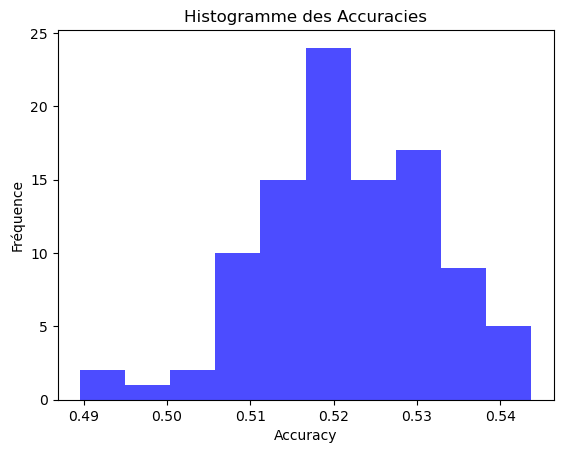

In [48]:
import matplotlib.pyplot as plt

#Calcul des moyennes et ecarts-types de l'accuracy
mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)
print(f"Mean Accuracy: {mean_accuracy:.4f}, Std Dev: {std_accuracy:.4f}")
print(f"95% chance of being better than: {mean_accuracy - 2.32*std_accuracy}")

# Affichage de l'histogramme des accuracies
plt.hist(accuracies, bins=10, alpha=0.7, color='blue')
plt.title('Histogramme des Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Fréquence')
plt.show()


These are the results we used to compare models, and decide wether one model was better than another.
The performance is under-evaluated compared to the true performance of the models on the private / public leaderboards, because not all training data is used.

Once the model and features were selected, we trained the model on X_test, y_test entirely, computed the features for X_test and then used the model to predict y_test.